# KNN Project


## The Sonar Data 

### Detecting a Rock or a Mine

Sonar (sound navigation ranging) is a technique that uses sound propagation (usually underwater, as in submarine navigation) to navigate, communicate with or detect objects on or under the surface of the water, such as other vessels.


The data set contains the response metrics for 60 separate sonar frequencies sent out against a known mine field (and known rocks). These frequencies are then labeled with the known object they were beaming the sound at (either a rock or a mine). 


My goal is to create a machine learning model capable of detecting the difference between a rock or a mine based on the response of the 60 separate sonar frequencies.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"D:\Python\KNN Project data\sonar.all-data.csv")

In [3]:
df.head()

,Freq_1,Freq_2,Freq_3,Freq_4,Freq_5,Freq_6,Freq_7,Freq_8,Freq_9,Freq_10,...,Freq_52,Freq_53,Freq_54,Freq_55,Freq_56,Freq_57,Freq_58,Freq_59,Freq_60,Label
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


---

## Exploring the data

In [4]:
print(df.shape) # 60 features! That's a lot

(208, 61)


In [7]:
print(df['Label'].value_counts()) # Not a major class imbalance, should be fine to continue here.

Label
M    111
R     97
Name: count, dtype: int64


In [9]:
print(df.isnull().sum().sum()) # No null values, that is good.

0


In [10]:
print(df.dtypes.value_counts())

float64    60
object      1
Name: count, dtype: int64


In [11]:
print(df.describe().T)

         count      mean       std     min       25%      50%       75%  \
Freq_1   208.0  0.029164  0.022991  0.0015  0.013350  0.02280  0.035550   
Freq_2   208.0  0.038437  0.032960  0.0006  0.016450  0.03080  0.047950   
Freq_3   208.0  0.043832  0.038428  0.0015  0.018950  0.03430  0.057950   
Freq_4   208.0  0.053892  0.046528  0.0058  0.024375  0.04405  0.064500   
Freq_5   208.0  0.075202  0.055552  0.0067  0.038050  0.06250  0.100275   
Freq_6   208.0  0.104570  0.059105  0.0102  0.067025  0.09215  0.134125   
Freq_7   208.0  0.121747  0.061788  0.0033  0.080900  0.10695  0.154000   
Freq_8   208.0  0.134799  0.085152  0.0055  0.080425  0.11210  0.169600   
Freq_9   208.0  0.178003  0.118387  0.0075  0.097025  0.15225  0.233425   
Freq_10  208.0  0.208259  0.134416  0.0113  0.111275  0.18240  0.268700   
Freq_11  208.0  0.236013  0.132705  0.0289  0.129250  0.22480  0.301650   
Freq_12  208.0  0.250221  0.140072  0.0236  0.133475  0.24905  0.331250   
Freq_13  208.0  0.273305 

### No missing values, no outliers, no type mismatches. Dataset is ready for modelling.

---

### Creating the Model

In [12]:
from sklearn.model_selection import train_test_split

In [14]:
# Splitting the Label
X = df.drop('Label', axis = 1)

In [16]:
y = df['Label'].map({'M': 1, 'R': 0})
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Label, dtype: int64

In [17]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

---

## Creating a Pipeline

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [34]:
# Using operations variable to later insert it into the pipeline
operations = [('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]

In [35]:
# Passing in the pipeline command
pipeline = Pipeline(operations)

In [36]:
print(pipeline)

Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])


---

## Introducting Cross Validation

In [37]:
from sklearn.model_selection import cross_validate

In [38]:
# Creating a baseline scoring, this will help us compare to the build after GridSearchCV
scores = cross_validate(pipeline, X_train, y_train, cv = 5, scoring = ['accuracy', 'recall', 'f1', 'precision'], return_train_score = True)

In [43]:
# Getting the baseline scores
print("Test Results:")
print("Accuracy:  ", round(scores['test_accuracy'].mean(), 2))
print("Recall:    ", round(scores['test_recall'].mean(), 2))
print("Precision: ", round(scores['test_precision'].mean(), 2))
print("F1:        ", round(scores['test_f1'].mean(), 2))

print("\nTrain Results:")
print("Accuracy:  ", round(scores['train_accuracy'].mean(), 2))
print("Recall:    ", round(scores['train_recall'].mean(), 2))

Test Results:
Accuracy:   0.79
Recall:     0.91
Precision:  0.75
F1:         0.82

Train Results:
Accuracy:   0.87
Recall:     0.96


Accuracy seems to be low with only 79% in test whereas in train results its 87%, the model is slightly overfitting. Time to play with K values using Grid search CV to find out the best K value

---

In [41]:
from sklearn.model_selection import GridSearchCV

In [69]:
# Using odd number of neighbors to prevent a draw, using uniform weight so that nearest neighbors vote equally and distance so that closer
# neighbors have more influence
param_grid = {'knn__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21], 'knn__weights': ['uniform', 'distance'], 'knn__metric': ['euclidean', 'manhattan']}

In [60]:
# Creating the GridSearch model
grid_search = GridSearchCV(pipeline, param_grid = param_grid, cv = 5, scoring = 'f1', n_jobs = -1, return_train_score = True)

In [61]:
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__metric': ['euclidean', 'manhattan'], 'knn__n_neighbors': [3, 5, ...], 'knn__weights': ['uniform', 'distance']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


In [62]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'knn__metric': 'euclidean', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
0.8689436919669479


----

## Testing the scores now

In [63]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [64]:
y_pred = grid_search.predict(X_test)

In [65]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.90      0.82      0.86        11

    accuracy                           0.86        21
   macro avg       0.86      0.86      0.86        21
weighted avg       0.86      0.86      0.86        21



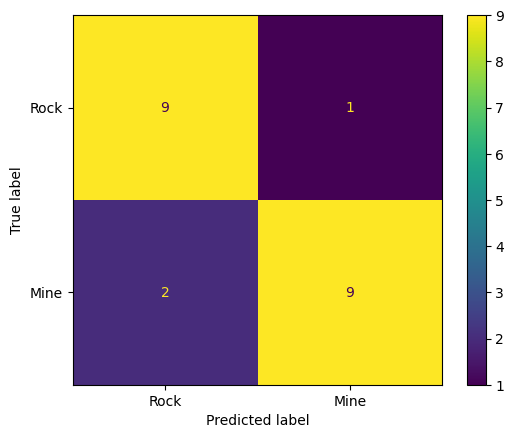

In [67]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels = ['Rock', 'Mine'])

---

## Inference from the results

The sonar model correctly identifies 86% of objects overall. When it flags something as a mine, it's right 90% of the time. It misses 2 out of every 11 real mines, meaning a small number of mines would go undetected. For a first pass detection system this is strong, but critical naval operations would need additional verification for anything the model labels as rock.

---